# MOUS Pilot: Subject A2002 — Aim 1 Phase Gradient Analysis

**Notebook lives inside `sub-A2002/` — paths are set accordingly.**

### Confirmed directory structure
- Single task run: `meg/sub-A2002_task-auditory_meg.ds`
- Rest run: `meg/sub-A2002_task-rest_meg.ds`
- Events: `meg/sub-A2002_task-auditory_events.tsv`
- T1 MRI: `anat/sub-A2002_T1w.nii`
- Note: `.1_meg4` file present → split run; MNE handles this automatically

### Key event structure facts (learned from PoC)
- Events file is a **continuous log**, not one-row-per-trial
- Condition (`ZINNEN` = sentences, `WOORDEN` = scrambled words) is encoded as **block-level** `Picture` markers — must be inherited forward to subsequent trials
- `trial` rows mark 10-second windows, **not** stimulus onset
- True neural time-locking point: `type == 'Nothing'` AND `value == '1 Audio onset'`
- Epoching at trial onset would include fixation/delay junk — always epoch at Audio onset

### Pipeline overview
1. Load & inspect raw CTF data
2. Parse events → build clean trial table with correct condition labels
3. Preprocess (gradient compensation, filter, ICA)
4. Epoch at **Audio onset** with pre-stimulus baseline
5. Aim 1: Phase gradient analysis — task vs. rest
6. Directional Consistency Index + rose plots
7. Sanity checks & go/no-go assessment

## 0. Imports & paths

In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'mne', 'mne-bids', 'pycircstat', 'tensorpac',
                'scikit-learn'],
               capture_output=True)
import mne
import mne_bids
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert
from scipy.stats import circmean

# ── Paths ──────────────────────────────────────────────────────────────────
# Notebook lives INSIDE sub-A2002/ — so '.' is the subject directory
SUBJECT  = 'A2002'
SUB_DIR  = Path('.')           # notebook is in sub-A2002/
MEG_DIR  = SUB_DIR / 'meg'
ANAT_DIR = SUB_DIR / 'anat'

# Single task run — confirmed from directory listing
# task name is 'auditory' (not 'languageMEG'), no run-index suffix
TASK_DS   = MEG_DIR / f'sub-{SUBJECT}_task-auditory_meg.ds'
REST_DS   = MEG_DIR / f'sub-{SUBJECT}_task-rest_meg.ds'
EVENTS_TSV = MEG_DIR / f'sub-{SUBJECT}_task-auditory_events.tsv'
T1_NII    = ANAT_DIR / f'sub-{SUBJECT}_T1w.nii'

# Verify all expected files exist before proceeding
for p in [TASK_DS, REST_DS, EVENTS_TSV, T1_NII]:
    status = '✓' if p.exists() else '✗ MISSING'
    print(f'{status}  {p}')

# Note: sub-A2002_task-auditory_meg.1_meg4 indicates a split run.
# MNE reads split CTF runs automatically — no special handling needed.

## 1. Load raw data & basic inspection

In [2]:
# Load the single task run
# system_clock='truncate' handles CTF clock drift warning
# MNE automatically detects and reads the .1_meg4 split file
raw = mne.io.read_raw_ctf(str(TASK_DS), preload=True,
                           system_clock='truncate', verbose='WARNING')

print(raw.info)
print(f"\nDuration: {raw.times[-1]:.1f} s")
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"MEG channels: {len(mne.pick_types(raw.info, meg=True))}")

# CTF-specific: apply synthetic 3rd-order gradient noise cancellation
# Uses reference channels to subtract environmental noise.
# Critical for axial gradiometers — do not skip.
raw.apply_gradient_compensation(3)
print("\nGradient compensation applied (order 3)")

<Info | 15 non-empty values
 bads: []
 ch_names: UDIO001, UPPT001, UPPT002, SCLK01-177, BG1-4304, BG2-4304, ...
 chs: 3 Stimulus, 44 misc, 28 Reference Magnetometers, 273 Magnetometers, 8 EEG
 comps: 5 items (list)
 ctf_head_t: CTF/4D/KIT head -> head transform
 custom_ref_applied: False
 dev_ctf_t: MEG device -> CTF/4D/KIT head transform
 dev_head_t: MEG device -> head transform
 dig: 11 items (3 Cardinal, 8 EEG)
 highpass: 0.0 Hz
 hpi_results: 1 item (list)
 lowpass: 600.0 Hz
 meas_date: 1970-01-01 09:49:00 UTC
 meas_id: 4 items (dict)
 nchan: 356
 projs: []
 sfreq: 1200.0 Hz
 subject_info: <subject_info | his_id: Anonymized388880_1534843214_0>
>

Duration: 2457.3 s
Sampling rate: 1200.0 Hz
MEG channels: 301
Compensator constructed to change 0 -> 3
Applying compensator to loaded data

Gradient compensation applied (order 3)


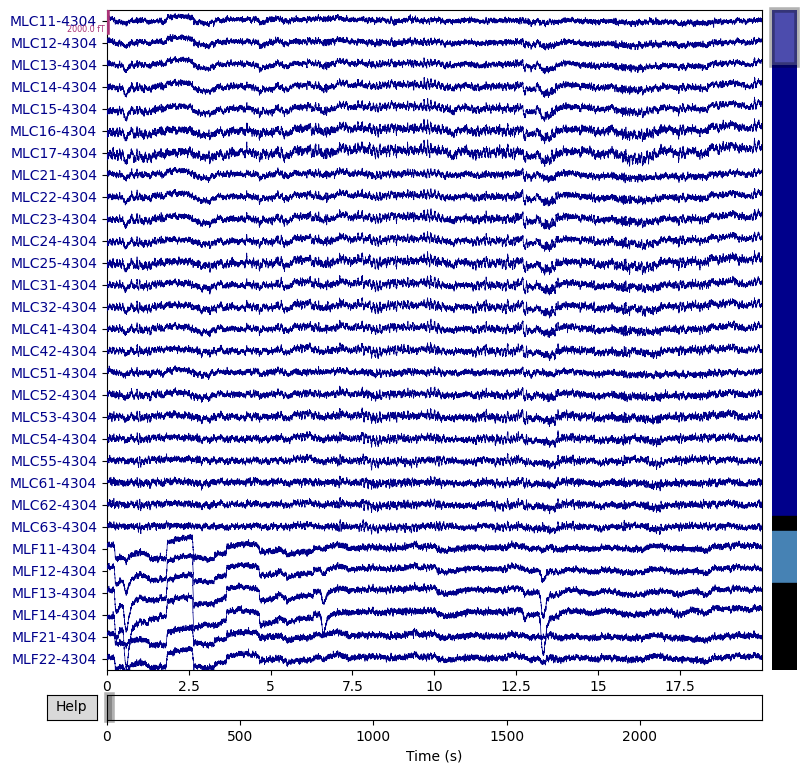

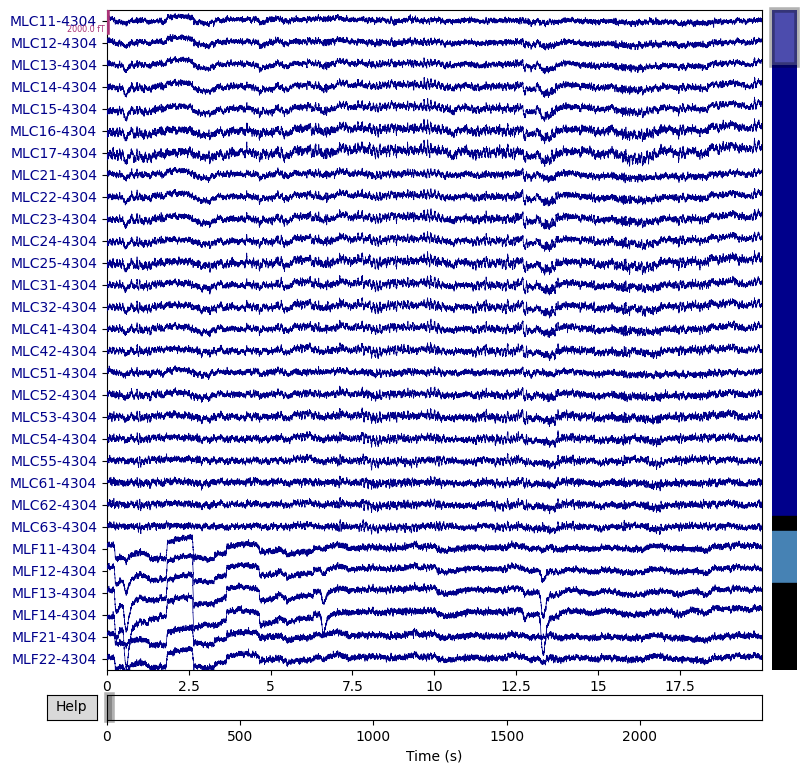

In [5]:
# Quick channel plot to check data quality before any processing
raw.plot(duration=20, n_channels=30, title='Raw CTF — first 20s', block=True)

## 2. Event parsing — the tricky part

The events file is a **continuous log** mixing trial markers, condition markers,
stimulus onsets, and responses. We need to:

1. Identify block-level condition from `Picture → ZINNEN/WOORDEN`
2. Forward-fill condition to all subsequent events until the next block marker
3. Extract only `Nothing → '1 Audio onset'` rows as epoch triggers
4. Each Audio onset inherits the condition of its containing block

In [6]:
def parse_events(tsv_path: Path) -> pd.DataFrame:
    """
    Parse the MOUS auditory events TSV into a clean trial table.

    Returns a DataFrame with columns: onset, sample, condition
    where condition is 'ZINNEN' (sentences) or 'WOORDEN' (scrambled words).

    Key facts about MOUS event structure:
    - File is a continuous log, NOT one row per trial
    - Condition encoded as block-level Picture markers (ZINNEN / WOORDEN)
      → must be forward-filled to subsequent events
    - True stimulus onset: type=='Nothing', value=='1 Audio onset'
    - 'trial' rows = 10s window start, NOT stimulus onset — do not use
    """
    df = pd.read_csv(tsv_path, sep='\t')
    df = df.sort_values('onset').reset_index(drop=True)

    print(f'Loaded {len(df)} events')
    print('Unique types:', df['type'].unique())
    print()
    display(df.head(30))

    # ── Step 1: forward-fill block condition ──────────────────────────────
    # Picture → ZINNEN  : sentences block starts
    # Picture → WOORDEN : scrambled word-list block starts
    condition_col = []
    current_cond  = None
    for _, row in df.iterrows():
        if row['type'] == 'Picture' and row['value'] in ('ZINNEN', 'WOORDEN'):
            current_cond = row['value']
        condition_col.append(current_cond)
    df['condition'] = condition_col

    # ── Step 2: keep only Audio onset rows ────────────────────────────────
    audio = df[
        (df['type'] == 'Nothing') &
        (df['value'].str.contains('Audio onset', na=False))
    ].copy()
    # Drop any onset before the first condition marker
    audio = audio.dropna(subset=['condition']).reset_index(drop=True)

    print(f'\nAudio onset events: {len(audio)}')
    print(audio['condition'].value_counts())
    return audio[['onset', 'sample', 'condition']]


all_trials = parse_events(EVENTS_TSV)
print(f'\n=== TOTAL TRIALS: {len(all_trials)} ===')

Loaded 2976 events
Unique types: ['trial' 'UPPT001' 'Picture' 'Sound' 'Nothing' 'UPPT002' 'Response'
 'frontpanel trigger' 'Pause' 'Resume' 'Quit']



,onset,duration,sample,type,value
0,0.000000,10.0,1,trial,NaN
1,7.077500,NaN,8494,UPPT001,10
2,7.077500,NaN,8494,Picture,ZINNEN
3,8.777500,NaN,10534,Picture,blank
4,10.000000,10.0,12001,trial,NaN
5,10.794167,NaN,12954,UPPT001,20
6,10.794167,NaN,12954,Picture,FIX 3516
7,12.317500,NaN,14782,Sound,14 Start File 186.wav
8,12.318333,NaN,14783,UPPT001,14
9,12.364167,NaN,14838,UPPT001,1



Audio onset events: 220
condition
ZINNEN     110
WOORDEN    110
Name: count, dtype: int64

=== TOTAL TRIALS: 220 ===


In [ ]:
sfreq = raw.info['sfreq']
CONDITION_IDS = {'ZINNEN': 1, 'WOORDEN': 2}

# Compute sample indices from onset times (seconds), not from the TSV 'sample'
# column — the TSV records at the original CTF rate (1200 Hz) and would give
# wrong indices after resampling.
events_array = np.column_stack([
    (all_trials['onset'] * sfreq).round().astype(int),
    np.zeros(len(all_trials), dtype=int),
    all_trials['condition'].map(CONDITION_IDS).astype(int)
])

print(f'Events array shape: {events_array.shape}')
print(f'Time range: {events_array[0,0]/sfreq:.1f}s → {events_array[-1,0]/sfreq:.1f}s')
print('First 10 events:\n', events_array[:10])

mne.viz.plot_events(events_array, sfreq=sfreq,
                    event_id={'ZINNEN (sentence)': 1, 'WOORDEN (scrambled)': 2})

## 3. Preprocessing

In [ ]:
import gc

# ── 3a. Notch filter in-place ─────────────────────────────────────────────
raw.notch_filter(freqs=[50, 100, 150], picks='meg', verbose='WARNING')

# ── 3b. Downsample to 300 Hz ──────────────────────────────────────────────
# 10× Nyquist for beta (13–30 Hz); shrinks every subsequent buffer by 4×.
# Must follow notch to avoid aliasing the 150 Hz harmonic.
# Note: MNE warns that resampled stim channels are unreliable — safe to ignore
# here because our events come from the TSV file (onset × sfreq), not stim ch.
raw.resample(300, npad='auto')
print(f"Resampled to {raw.info['sfreq']} Hz  ({raw.n_times} samples)")

# ── 3c. One copy for ICA fitting (1–100 Hz) ───────────────────────────────
# Filter all channels (not picks='meg') so MNE updates info['highpass'] — it
# only does so when the whole recording is filtered, not a channel subset.
# ICA will still only use MEG picks; non-MEG channels being filtered is harmless.
raw_ica_fit = raw.copy()
raw_ica_fit.filter(1, 100, method='fir', fir_window='hamming', verbose='WARNING')

print(f"Broadband filter applied  |  highpass={raw_ica_fit.info['highpass']} Hz")

In [9]:
# ── 3c. ICA artifact removal ───────────────────────────────────────────────
# n_components=40 is reasonable for 275-channel CTF data
from mne.preprocessing import ICA

ica = ICA(n_components=40, random_state=42, method='fastica', max_iter='auto')
ica.fit(raw_ica_fit, picks='meg')

print(f"ICA fitted: {ica.n_components_} components")

# Plot components for manual inspection
# Look for: large heartbeat (~1 Hz sinusoid), eye blinks (frontal, slow)
ica.plot_sources(raw_ica_fit, block=True,
                  title='ICA sources — identify ECG/EOG components')

ImportError: The sklearn package is required to use method='fastica', package was not found

In [ ]:
# After visual inspection above, set exclusions here:
# ica.exclude = [0, 1]  # <-- fill in component indices you identified

# threshold=0.9 avoids flagging brain components that weakly correlate with
# the reconstructed ECG signal; cap at 3 regardless as a safety net.
ecg_indices, ecg_scores = ica.find_bads_ecg(raw, method='correlation', threshold=0.9)
print(f"Auto-detected ECG components: {ecg_indices}")
if len(ecg_indices) > 3:
    top3 = sorted(range(len(ecg_scores)), key=lambda i: abs(ecg_scores[i]), reverse=True)[:3]
    ecg_indices = [ecg_indices[i] for i in sorted(top3)]
    print(f"Capped to top 3 by score: {ecg_indices}")

try:
    eog_indices, eog_scores = ica.find_bads_eog(raw)
    print(f"Auto-detected EOG components: {eog_indices}")
except RuntimeError as e:
    eog_indices = []
    print(f"EOG auto-detection skipped ({e}). Inspect ICA sources manually.")

ica.exclude = list(set(ecg_indices + eog_indices))
print(f"Excluding: {ica.exclude}")

del raw_ica_fit
gc.collect()

ica.apply(raw)
raw_clean = raw
print("ICA applied")

In [ ]:
# ── 3d. Beta-band filter in-place ─────────────────────────────────────────
raw_clean.filter(
    l_freq=13, h_freq=30,
    picks='meg',
    method='fir',
    fir_window='hamming',
    verbose='WARNING'
)
raw_beta = raw_clean  # alias, no copy

print("Beta bandpass filter applied (13–30 Hz)")

## 4. Epoching at Audio onset

**Critical**: epoch at `1 Audio onset` events, not at `trial` onset.
- `tmin = -0.5` s gives a clean pre-stimulus baseline (after fixation, before speech)
- `tmax = 3.0` s captures the full sentence (Dutch sentences in MOUS ~2–3 s)
- Baseline correction using the pre-stimulus window

In [ ]:
TMIN, TMAX = -0.5, 3.0
BASELINE   = (-0.5, 0.0)

# Fix: events_array was created when raw was at 1200 Hz (before resample).
# Recompute sample indices at the current 300 Hz sfreq using onset times.
events_array[:, 0] = (all_trials['onset'] * raw_beta.info['sfreq']).round().astype(int)
print(f"Events reindexed at {raw_beta.info['sfreq']} Hz  "
      f"(range: {events_array[0,0]} – {events_array[-1,0]})")

if len(raw_beta.annotations) > 0:
    from collections import Counter as _Counter
    ann_counts = _Counter(raw_beta.annotations.description)
    print("Annotations in raw_beta:")
    for desc, n in ann_counts.most_common():
        print(f"  {desc!r}: {n}")
else:
    print("No annotations in raw_beta")

epochs = mne.Epochs(
    raw_beta,
    events_array,
    event_id=CONDITION_IDS,
    tmin=TMIN,
    tmax=TMAX,
    baseline=BASELINE,
    picks='meg',
    preload=True,
    reject={'mag': 4e-12},
    flat={'mag': 1e-15},
    reject_by_annotation=False,
    verbose='WARNING'
)

print(epochs)
print(f"\nEpochs surviving rejection:")
for cond, eid in CONDITION_IDS.items():
    n = len(epochs[cond])
    print(f"  {cond}: {n} epochs")
    if n < 50:
        print(f"  WARNING: only {n} {cond} epochs — may be underpowered")

from collections import Counter
all_bad_chs = [ch for d in epochs.drop_log for ch in d if ch != 'IGNORED']
ch_counts = Counter(all_bad_chs).most_common(10)
n_original = sum(1 for d in epochs.drop_log if d != ('IGNORED',))
n_dropped  = sum(1 for d in epochs.drop_log if len(d) > 0 and d != ('IGNORED',))
print(f"\nDrop rate: {n_dropped}/{n_original} ({100*n_dropped/max(n_original,1):.0f}%)"
      f"  —  threshold mag=4e-12 T")
if ch_counts:
    print("Top channels driving rejections:")
    for ch, count in ch_counts:
        print(f"  {ch}: {count} epochs")

In [ ]:
# Epochs are preloaded — raw data is no longer needed
del raw, raw_clean, raw_beta
gc.collect()
print("Raw task data freed from memory")

In [ ]:
evoked_zinnen  = epochs['ZINNEN'].average()
evoked_woorden = epochs['WOORDEN'].average()

evoked_zinnen.plot(spatial_colors=True, gfp=True,
                   titles='Average evoked — ZINNEN (sentences)', time_unit='s')

## 5. Load resting-state data

In [ ]:
raw_rest = mne.io.read_raw_ctf(str(REST_DS), preload=True,
                                system_clock='truncate', verbose='WARNING')
raw_rest.apply_gradient_compensation(3)

# Mirror task preprocessing exactly, all in-place
raw_rest.notch_filter(freqs=[50, 100, 150], picks='meg', verbose='WARNING')
raw_rest.resample(300, npad='auto')
ica.apply(raw_rest)
raw_rest.filter(13, 30, picks='meg',
                method='fir', fir_window='hamming',
                verbose='WARNING')
raw_rest_beta = raw_rest  # alias, no copy

# Segment rest into pseudo-epochs matching task epoch length
rest_duration = raw_rest.times[-1]
epoch_len = TMAX - TMIN  # 3.5 s
n_rest_epochs = int(rest_duration // epoch_len)
print(f"Rest duration: {rest_duration:.1f} s → {n_rest_epochs} pseudo-epochs of {epoch_len} s")

rest_events = mne.make_fixed_length_events(
    raw_rest_beta, id=99, duration=epoch_len, overlap=0.0
)

epochs_rest = mne.Epochs(
    raw_rest_beta, rest_events, event_id={'rest': 99},
    tmin=0, tmax=epoch_len - 1/raw_rest.info['sfreq'],
    baseline=None, picks='meg',
    preload=True, reject={'mag': 4e-12}, verbose='WARNING'
)

print(f"Rest epochs surviving rejection: {len(epochs_rest)}")

del raw_rest, raw_rest_beta
gc.collect()
print("Raw rest data freed from memory")

## 6. Phase gradient analysis (Aim 1)

For each epoch, at each time point:
1. Extract instantaneous phase via Hilbert transform across all MEG sensors
2. Fit a planar wave model: φ = kx·x + ky·y + φ₀ (least squares over sensor positions)
3. Wave direction = arctan2(ky, kx)
4. Aggregate per epoch → Directional Consistency Index (DCI)

Then compare DCI: task (ZINNEN) vs. rest.

In [ ]:
def get_sensor_positions(info):
    """Extract 2D (x, y) sensor positions in metres from MNE info."""
    meg_picks = mne.pick_types(info, meg=True, exclude='bads')
    pos = np.array([
        info['chs'][p]['loc'][:3] for p in meg_picks
    ])  # (n_sensors, 3)
    return pos[:, :2], meg_picks  # return x,y only + channel indices


def compute_wave_directions(data_beta, sensor_xy):
    """
    Compute instantaneous wave propagation direction at each time point.
    
    Parameters
    ----------
    data_beta : np.ndarray, shape (n_sensors, n_times)
        Beta-filtered MEG data.
    sensor_xy : np.ndarray, shape (n_sensors, 2)
        Sensor x, y positions in metres.
    
    Returns
    -------
    directions : np.ndarray, shape (n_times,)
        Wave direction in radians at each time point.
    speeds : np.ndarray, shape (n_times,)
        Estimated wave speed (m/s) — noisy, treat with caution.
    """
    analytic  = hilbert(data_beta, axis=1)
    phase     = np.angle(analytic)          # (n_sensors, n_times)
    n_times   = phase.shape[1]
    
    # Design matrix: [x, y, 1] for each sensor
    A = np.column_stack([sensor_xy[:, 0],
                         sensor_xy[:, 1],
                         np.ones(len(sensor_xy))])
    
    # Solve for wave vector at each time point via least squares
    # phase[:, t] = A @ [kx, ky, phi0]
    # Use pseudoinverse for speed (A is constant across time)
    A_pinv = np.linalg.pinv(A)             # (3, n_sensors)
    k_vec  = A_pinv @ phase                # (3, n_times): rows = kx, ky, phi0
    
    kx, ky    = k_vec[0], k_vec[1]
    directions = np.arctan2(ky, kx)        # radians
    k_mag      = np.sqrt(kx**2 + ky**2)
    
    # Speed estimate: temporal frequency / spatial frequency
    # Use centre of beta band (21.5 Hz) as nominal frequency
    f_centre = 21.5  # Hz
    with np.errstate(divide='ignore', invalid='ignore'):
        speeds = np.where(k_mag > 1e-6,
                          2 * np.pi * f_centre / k_mag,
                          np.nan)
    return directions, speeds


def directional_consistency_index(directions):
    """Mean resultant vector length — 0 = uniform, 1 = perfectly consistent."""
    return np.abs(np.mean(np.exp(1j * directions)))


# Get sensor positions from task data
sensor_xy, meg_picks = get_sensor_positions(epochs.info)
print(f"Using {len(meg_picks)} MEG sensors for phase gradient")

In [ ]:
def epochs_to_directions(epochs_obj, sensor_xy, meg_picks, desc=''):
    """
    Compute per-epoch directional distributions from an Epochs object.
    Returns directions pooled across all epochs and time points.
    """
    all_directions = []
    all_dci        = []
    
    data = epochs_obj.get_data(picks=meg_picks)  # (n_epochs, n_sensors, n_times)
    
    for i_ep, ep_data in enumerate(data):
        dirs, _ = compute_wave_directions(ep_data, sensor_xy)
        all_directions.append(dirs)
        all_dci.append(directional_consistency_index(dirs))
    
    directions_pooled = np.concatenate(all_directions)
    dci_mean = np.mean(all_dci)
    dci_sem  = np.std(all_dci) / np.sqrt(len(all_dci))
    
    print(f"{desc}: {len(data)} epochs, "
          f"DCI = {dci_mean:.4f} ± {dci_sem:.4f}")
    return directions_pooled, np.array(all_dci)


# ── Compute for each condition ─────────────────────────────────────────────
dirs_zinnen,  dci_zinnen  = epochs_to_directions(
    epochs['ZINNEN'],  sensor_xy, meg_picks, 'ZINNEN (sentences)')

dirs_woorden, dci_woorden = epochs_to_directions(
    epochs['WOORDEN'], sensor_xy, meg_picks, 'WOORDEN (scrambled)')

dirs_rest,    dci_rest    = epochs_to_directions(
    epochs_rest,       sensor_xy, meg_picks, 'REST')

In [ ]:
# ── Rayleigh test for directional non-uniformity ───────────────────────────
# Uses astropy or pycircstat — install if needed:
# pip install pycircstat
try:
    import pycircstat
    def rayleigh_p(angles):
        return pycircstat.tests.rayleigh(angles)[1]
except ImportError:
    # Manual implementation if pycircstat not available
    def rayleigh_p(angles):
        n = len(angles)
        R = np.abs(np.sum(np.exp(1j * angles)))
        z = R**2 / n
        # Approximation (Zar 1999)
        p = np.exp(-z) * (1 + (2*z - z**2) / (4*n) - (24*z - 132*z**2 + 76*z**3 - 9*z**4) / (288*n**2))
        return float(np.clip(p, 0, 1))

print("=== Rayleigh test (H0: uniform direction) ===")
for label, dirs in [('ZINNEN',  dirs_zinnen),
                     ('WOORDEN', dirs_woorden),
                     ('REST',    dirs_rest)]:
    dci = directional_consistency_index(dirs)
    p   = rayleigh_p(dirs)
    mean_dir_deg = np.degrees(circmean(dirs))
    print(f"  {label:<10} DCI={dci:.4f}  mean_dir={mean_dir_deg:+.1f}°  p={p:.4e}")

In [ ]:
# ── DCI comparison: task vs rest (permutation test) ───────────────────────
def permutation_dci_test(dci_a, dci_b, n_permutations=5000, rng_seed=42):
    """
    Test whether mean(dci_a) > mean(dci_b) via permutation.
    Returns observed difference and p-value.
    """
    rng     = np.random.default_rng(rng_seed)
    obs_diff = np.mean(dci_a) - np.mean(dci_b)
    pooled  = np.concatenate([dci_a, dci_b])
    n_a     = len(dci_a)
    
    null_dist = []
    for _ in range(n_permutations):
        perm     = rng.permutation(pooled)
        null_dist.append(np.mean(perm[:n_a]) - np.mean(perm[n_a:]))
    
    p_val = np.mean(np.array(null_dist) >= obs_diff)
    return obs_diff, p_val


diff_sz, p_sz = permutation_dci_test(dci_zinnen, dci_rest)
diff_wz, p_wz = permutation_dci_test(dci_zinnen, dci_woorden)

print("=== DCI permutation tests ===")
print(f"  ZINNEN vs REST:    ΔDCI={diff_sz:+.4f}  p={p_sz:.4f}")
print(f"  ZINNEN vs WOORDEN: ΔDCI={diff_wz:+.4f}  p={p_wz:.4f}")
print()
print("Interpretation:")
print("  p < 0.05 ZINNEN > REST    → task increases directional coherence ✓")
print("  p < 0.05 ZINNEN > WOORDEN → compositional language specifically ✓")

## 7. Visualisation — Rose plots

In [ ]:
def rose_plot(ax, angles, title, color, n_bins=36):
    """Circular histogram (rose plot) of wave directions."""
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    counts, _  = np.histogram(angles, bins=bin_edges)
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    width       = 2 * np.pi / n_bins
    
    bars = ax.bar(bin_centres, counts / counts.max(),
                  width=width * 0.9, bottom=0.0,
                  color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
    
    # Plot mean direction arrow
    mean_dir = circmean(angles)
    dci_val  = directional_consistency_index(angles)
    ax.annotate('', xy=(mean_dir, dci_val),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    
    ax.set_theta_zero_location('E')   # 0° = anterior (right)
    ax.set_theta_direction(1)          # counterclockwise
    ax.set_title(f'{title}\nDCI={dci_val:.3f}', pad=12, fontsize=10)
    ax.set_rticks([])                  # hide radial ticks
    
    # Label cardinal directions
    ax.set_xticks(np.radians([0, 90, 180, 270]))
    ax.set_xticklabels(['Ant', 'Left', 'Post', 'Right'], fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(12, 4),
                          subplot_kw={'projection': 'polar'})

rose_plot(axes[0], dirs_zinnen,  'ZINNEN\n(sentences)',  '#2166ac')
rose_plot(axes[1], dirs_woorden, 'WOORDEN\n(scrambled)', '#92c5de')
rose_plot(axes[2], dirs_rest,    'REST',                  '#d6604d')

fig.suptitle(f'Beta-band traveling wave directions — sub-{SUBJECT}',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'sub-{SUBJECT}_wave_directions_beta.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sub-A2002_wave_directions_beta.png")

In [ ]:
# ── Time-resolved DCI: does coherence build after Audio onset? ────────────
# Slice only the post-onset window from ZINNEN epochs
# and compute DCI in sliding windows

WINDOW_S = 0.2   # 200 ms sliding window
STEP_S   = 0.05  # 50 ms step

sfreq    = epochs.info['sfreq']
win_samp = int(WINDOW_S * sfreq)
step_samp= int(STEP_S   * sfreq)
times    = epochs.times

data_z   = epochs['ZINNEN'].get_data(picks=meg_picks)   # (n_ep, n_sens, n_t)
data_w   = epochs['WOORDEN'].get_data(picks=meg_picks)

def sliding_dci(data, win, step):
    """DCI averaged across epochs in sliding windows. Returns (n_windows,) array."""
    n_ep, n_sens, n_t = data.shape
    centres = []
    dci_ts  = []
    for start in range(0, n_t - win, step):
        seg = data[:, :, start:start+win]
        ep_dci = []
        for ep in seg:
            dirs, _ = compute_wave_directions(ep, sensor_xy)
            ep_dci.append(directional_consistency_index(dirs))
        dci_ts.append(np.mean(ep_dci))
        centres.append(times[start + win//2])
    return np.array(centres), np.array(dci_ts)

print("Computing time-resolved DCI (this may take ~1–2 minutes)...")
t_z, dci_z_ts = sliding_dci(data_z, win_samp, step_samp)
t_w, dci_w_ts = sliding_dci(data_w, win_samp, step_samp)
print("Done")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(t_z, dci_z_ts, color='#2166ac', lw=2, label='ZINNEN (sentences)')
ax.plot(t_w, dci_w_ts, color='#92c5de', lw=2, label='WOORDEN (scrambled)')
ax.axvline(0, color='k', ls='--', lw=1, label='Audio onset')
ax.axhspan(*ax.get_ylim(), alpha=0)  # force ylim evaluation

ax.set_xlabel('Time relative to Audio onset (s)')
ax.set_ylabel('Directional Consistency Index')
ax.set_title(f'Beta-band DCI over time — sub-{SUBJECT}')
ax.legend()
ax.set_xlim(times[0], times[-1])

plt.tight_layout()
plt.savefig(f'sub-{SUBJECT}_DCI_timecourse.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Go / No-Go assessment

Evaluate whether the pilot results support proceeding to the full cohort.

In [ ]:
print("=" * 60)
print("PILOT ASSESSMENT — sub-A2002")
print("=" * 60)

n_zinnen  = len(epochs['ZINNEN'])
n_woorden = len(epochs['WOORDEN'])
n_rest_ep = len(epochs_rest)

dci_z_mean = np.mean(dci_zinnen)
dci_r_mean = np.mean(dci_rest)

print(f"\n[EPOCHS]")
print(f"  ZINNEN:  {n_zinnen}  {'✓' if n_zinnen >= 50 else '⚠ LOW'}")
print(f"  WOORDEN: {n_woorden} {'✓' if n_woorden >= 50 else '⚠ LOW'}")
print(f"  REST:    {n_rest_ep} {'✓' if n_rest_ep >= 50 else '⚠ LOW'}")

print(f"\n[PHASE GRADIENT]")
print(f"  DCI ZINNEN:  {dci_z_mean:.4f}")
print(f"  DCI REST:    {dci_r_mean:.4f}")
print(f"  Task > Rest: {'✓' if dci_z_mean > dci_r_mean else '✗'}  (p={p_sz:.4f})")

print(f"\n[DIRECTIONAL UNIFORMITY]")
p_zinnen_rayleigh  = rayleigh_p(dirs_zinnen)
p_rest_rayleigh    = rayleigh_p(dirs_rest)
print(f"  Rayleigh p ZINNEN: {p_zinnen_rayleigh:.4e} {'✓ non-uniform' if p_zinnen_rayleigh < 0.05 else '✗ uniform — no preferred direction'}")
print(f"  Rayleigh p REST:   {p_rest_rayleigh:.4e}")

print()
go_criteria = [
    (n_zinnen >= 50,                        "≥50 ZINNEN epochs"),
    (dci_z_mean > dci_r_mean,               "Task DCI > Rest DCI"),
    (p_sz < 0.05,                           "DCI difference significant (p<0.05)"),
    (p_zinnen_rayleigh < 0.05,              "Non-uniform direction in task"),
]

n_pass = sum(c for c, _ in go_criteria)
print("GO / NO-GO CRITERIA:")
for passed, label in go_criteria:
    print(f"  {'✓' if passed else '✗'} {label}")

print()
if n_pass == 4:
    print("→ GO: proceed to full cohort and two-dipole simulation")
elif n_pass >= 2:
    print("→ MARGINAL: review rose plots manually before proceeding")
else:
    print("→ NO-GO: sensor-level traveling wave analysis not viable.")
    print("   Consider: (a) source-level analysis, (b) Grabot et al. model-based approach,")
    print("   or (c) pivot to Aim 2 (cross-frequency coupling) only.")

## 9. Save outputs

In [ ]:
epochs.save(f'sub-{SUBJECT}_task-auditory_beta-epo.fif', overwrite=True)
epochs_rest.save(f'sub-{SUBJECT}_task-rest_beta-epo.fif', overwrite=True)

all_trials.to_csv(f'sub-{SUBJECT}_trial_table.csv', index=False)

np.save(f'sub-{SUBJECT}_dirs_zinnen.npy',  dirs_zinnen)
np.save(f'sub-{SUBJECT}_dirs_woorden.npy', dirs_woorden)
np.save(f'sub-{SUBJECT}_dirs_rest.npy',    dirs_rest)

print('Saved:')
print(f'  sub-{SUBJECT}_task-auditory_beta-epo.fif')
print(f'  sub-{SUBJECT}_task-rest_beta-epo.fif')
print(f'  sub-{SUBJECT}_trial_table.csv')
print(f'  sub-{SUBJECT}_dirs_*.npy')

## 10. Source-level phase gradient analysis

Sensor-level planar wave fitting is unreliable for CTF axial gradiometers — radial field measurements mix contributions from distributed sources, producing near-uniform direction distributions regardless of true wave activity. Projecting to source space first removes this geometry problem.

Pipeline:
1. Coregister fsaverage template MRI to MEG fiducials (nasion, LPA, RPA)
2. Build LCMV beamformer from baseline + active covariance
3. Apply to beta-filtered epochs → source timeseries (~2052 cortical sources)
4. Re-run DCI analysis on source data and compare with sensor-level result

**Note:** Template coregistration is a rough alignment sufficient for a single-subject pilot. For the full cohort, replace with subject-specific FreeSurfer surfaces and manual coregistration.

In [ ]:
import os
import glob
from mne.coreg import Coregistration
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from sklearn.decomposition import PCA as _PCA

# ── 10a. Coregistration ────────────────────────────────────────────────────
_fs_path = mne.datasets.fetch_fsaverage(verbose='WARNING')

# fetch_fsaverage returns either the subjects_dir (parent of fsaverage/)
# or the fsaverage/ directory itself, depending on MNE version.
if os.path.basename(_fs_path) == 'fsaverage':
    fsaverage_dir    = _fs_path
    coreg_subj_dir   = os.path.dirname(_fs_path)   # parent, for Coregistration
else:
    coreg_subj_dir   = _fs_path
    fsaverage_dir    = os.path.join(_fs_path, 'fsaverage')

bem_dir = os.path.join(fsaverage_dir, 'bem')
print(f"fsaverage dir : {fsaverage_dir}")
print(f"BEM dir       : {bem_dir}")
print(f"BEM contents  : {sorted(os.listdir(bem_dir))}")

# Coregistration requires fsaverage-head.fif (outer scalp surface).
# fetch_fsaverage doesn't ship it, so we extract the outer skin from the
# 3-layer BEM model and write it once.
head_fif = os.path.join(bem_dir, 'fsaverage-head.fif')
if not os.path.exists(head_fif):
    print("Creating fsaverage-head.fif from BEM model...")
    bem_model_path = os.path.join(bem_dir, 'fsaverage-5120-5120-5120-bem.fif')
    if not os.path.exists(bem_model_path):
        raise FileNotFoundError(
            f"Expected BEM model at {bem_model_path}\n"
            f"BEM dir contains: {sorted(os.listdir(bem_dir))}"
        )
    from mne.io.constants import FIFF as _FIFF
    _surfs = mne.read_bem_surfaces(bem_model_path, verbose='WARNING')
    _head = next(
        (s for s in _surfs if s['id'] == _FIFF.FIFFV_BEM_SURF_ID_HEAD),
        _surfs[0]
    )
    mne.write_bem_surfaces(head_fif, [_head], verbose='WARNING')
    print(f"  Written: {head_fif}")
else:
    print(f"Head surface already exists.")

coreg = Coregistration(epochs.info, 'fsaverage', subjects_dir=coreg_subj_dir)
coreg.fit_fiducials(verbose='WARNING')
trans = coreg.trans
print("Template MRI coregistered to MEG fiducials")

# ── 10b. Forward model ─────────────────────────────────────────────────────
src_path = os.path.join(bem_dir, 'fsaverage-ico-5-src.fif')
if os.path.exists(src_path):
    src = mne.read_source_spaces(src_path, verbose='WARNING')
else:
    src = mne.setup_source_space('fsaverage', spacing='oct5',
                                  subjects_dir=coreg_subj_dir, verbose='WARNING')

bem_sol_path = os.path.join(bem_dir, 'fsaverage-5120-5120-5120-bem-sol.fif')
if os.path.exists(bem_sol_path):
    bem_sol = mne.read_bem_solution(bem_sol_path, verbose='WARNING')
else:
    _bem_surfaces = mne.make_bem_model('fsaverage', ico=4,
                                        subjects_dir=coreg_subj_dir, verbose='WARNING')
    bem_sol = mne.make_bem_solution(_bem_surfaces, verbose='WARNING')

fwd = mne.make_forward_solution(
    epochs.info, trans=trans, src=src, bem=bem_sol,
    meg=True, eeg=False, verbose='WARNING'
)
fwd = mne.convert_forward_solution(fwd, surf_ori=True, verbose='WARNING')
print(f"Forward model: {fwd['nsource']} sources")

# ── 10c. LCMV beamformer ───────────────────────────────────────────────────
noise_cov = mne.compute_covariance(epochs, tmax=0.0, method='empirical', verbose='WARNING')
data_cov  = mne.compute_covariance(epochs, tmin=0.0, tmax=3.0, method='empirical', verbose='WARNING')

filters = make_lcmv(
    epochs.info, fwd, data_cov,
    reg=0.05, noise_cov=noise_cov,
    pick_ori='max-power', weight_norm='unit-noise-gain',
    verbose='WARNING'
)
print("LCMV filters computed")

# 2D projection of source positions for planar wave fitting
src_pos = np.vstack([s['rr'][s['inuse'].astype(bool)] for s in fwd['src']])
src_xy_2d = _PCA(n_components=2).fit_transform(src_pos)
print(f"Source positions projected to 2D: {len(src_xy_2d)} sources")

In [ ]:
# ── 10d. Source DCI — generator-based to avoid RAM spike ──────────────────
def source_epochs_to_directions(epochs_obj, filters, src_xy, desc=''):
    all_dci, all_dirs = [], []
    for stc in apply_lcmv_epochs(epochs_obj, filters,
                                  return_generator=True, verbose=False):
        dirs, _ = compute_wave_directions(stc.data, src_xy)
        all_dci.append(directional_consistency_index(dirs))
        all_dirs.append(dirs)
    dci_arr    = np.array(all_dci)
    dirs_pooled = np.concatenate(all_dirs)
    print(f"{desc}: {len(all_dci)} epochs, "
          f"DCI = {dci_arr.mean():.4f} ± {dci_arr.std()/np.sqrt(len(dci_arr)):.4f}")
    return dirs_pooled, dci_arr

print("Computing source-level DCI (may take a few minutes)...")
dirs_src_z, dci_src_z = source_epochs_to_directions(
    epochs['ZINNEN'],  filters, src_xy_2d, 'ZINNEN  (source)')
dirs_src_w, dci_src_w = source_epochs_to_directions(
    epochs['WOORDEN'], filters, src_xy_2d, 'WOORDEN (source)')
dirs_src_r, dci_src_r = source_epochs_to_directions(
    epochs_rest,       filters, src_xy_2d, 'REST    (source)')

# Permutation tests
diff_sz_src, p_sz_src = permutation_dci_test(dci_src_z, dci_src_r)
diff_wz_src, p_wz_src = permutation_dci_test(dci_src_z, dci_src_w)

print(f"\n=== Source-level permutation tests ===")
print(f"  ZINNEN vs REST:    ΔDCI={diff_sz_src:+.4f}  p={p_sz_src:.4f}")
print(f"  ZINNEN vs WOORDEN: ΔDCI={diff_wz_src:+.4f}  p={p_wz_src:.4f}")

print(f"\n=== Sensor vs Source DCI comparison ===")
print(f"  {'Condition':<10} {'Sensor':>10} {'Source':>10}")
for label, d_sens, d_src in [
    ('ZINNEN',  dci_zinnen,  dci_src_z),
    ('WOORDEN', dci_woorden, dci_src_w),
    ('REST',    dci_rest,    dci_src_r),
]:
    print(f"  {label:<10} {np.mean(d_sens):>10.4f} {np.mean(d_src):>10.4f}")

# Rose plots
fig, axes = plt.subplots(1, 3, figsize=(12, 4), subplot_kw={'projection': 'polar'})
rose_plot(axes[0], dirs_src_z, 'ZINNEN\n(source)',  '#2166ac')
rose_plot(axes[1], dirs_src_w, 'WOORDEN\n(source)', '#92c5de')
rose_plot(axes[2], dirs_src_r, 'REST\n(source)',     '#d6604d')
fig.suptitle(f'Source-level beta-band wave directions — sub-{SUBJECT}',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'sub-{SUBJECT}_source_wave_directions_beta.png', dpi=150, bbox_inches='tight')
plt.show()